Dataset shape: (33, 20)
Columns: ['Timestamp', 'What is your age?', 'Occupitation', 'P1.Q1', 'P1.Q2', 'P1.Q3', 'P1.Q4', 'P1.Q5', 'P1.Q6', 'P2.Q1', 'P2.Q2', 'P2.Q3', 'P2.Q4', 'P2.Q5', 'P2.Q6', 'P2.Q7', 'P2.Q8', 'P2.Q9', 'P2.Q10', 'Reasoning']


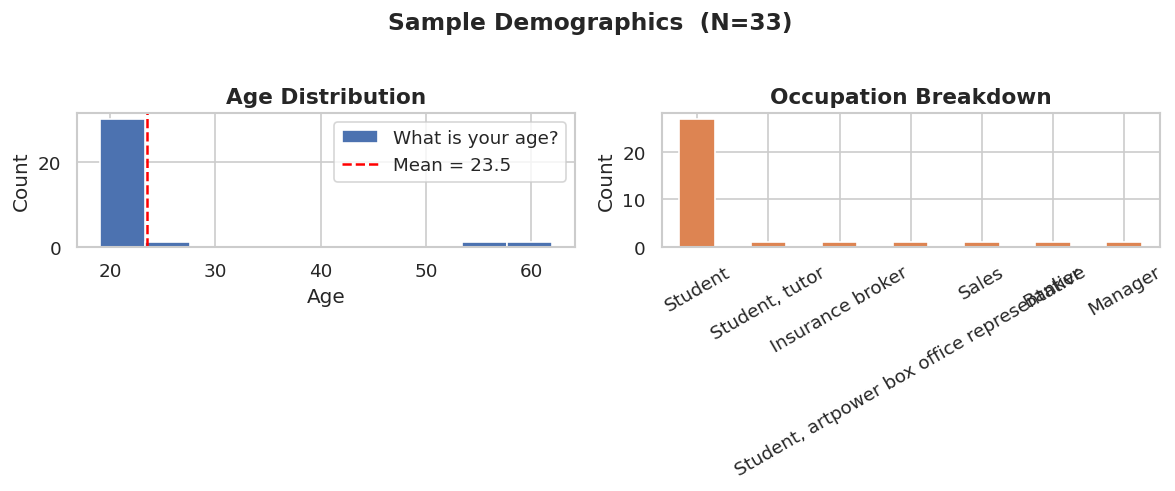

N = 33 | Age: M=23.5, SD=9.3
Binary coding complete.


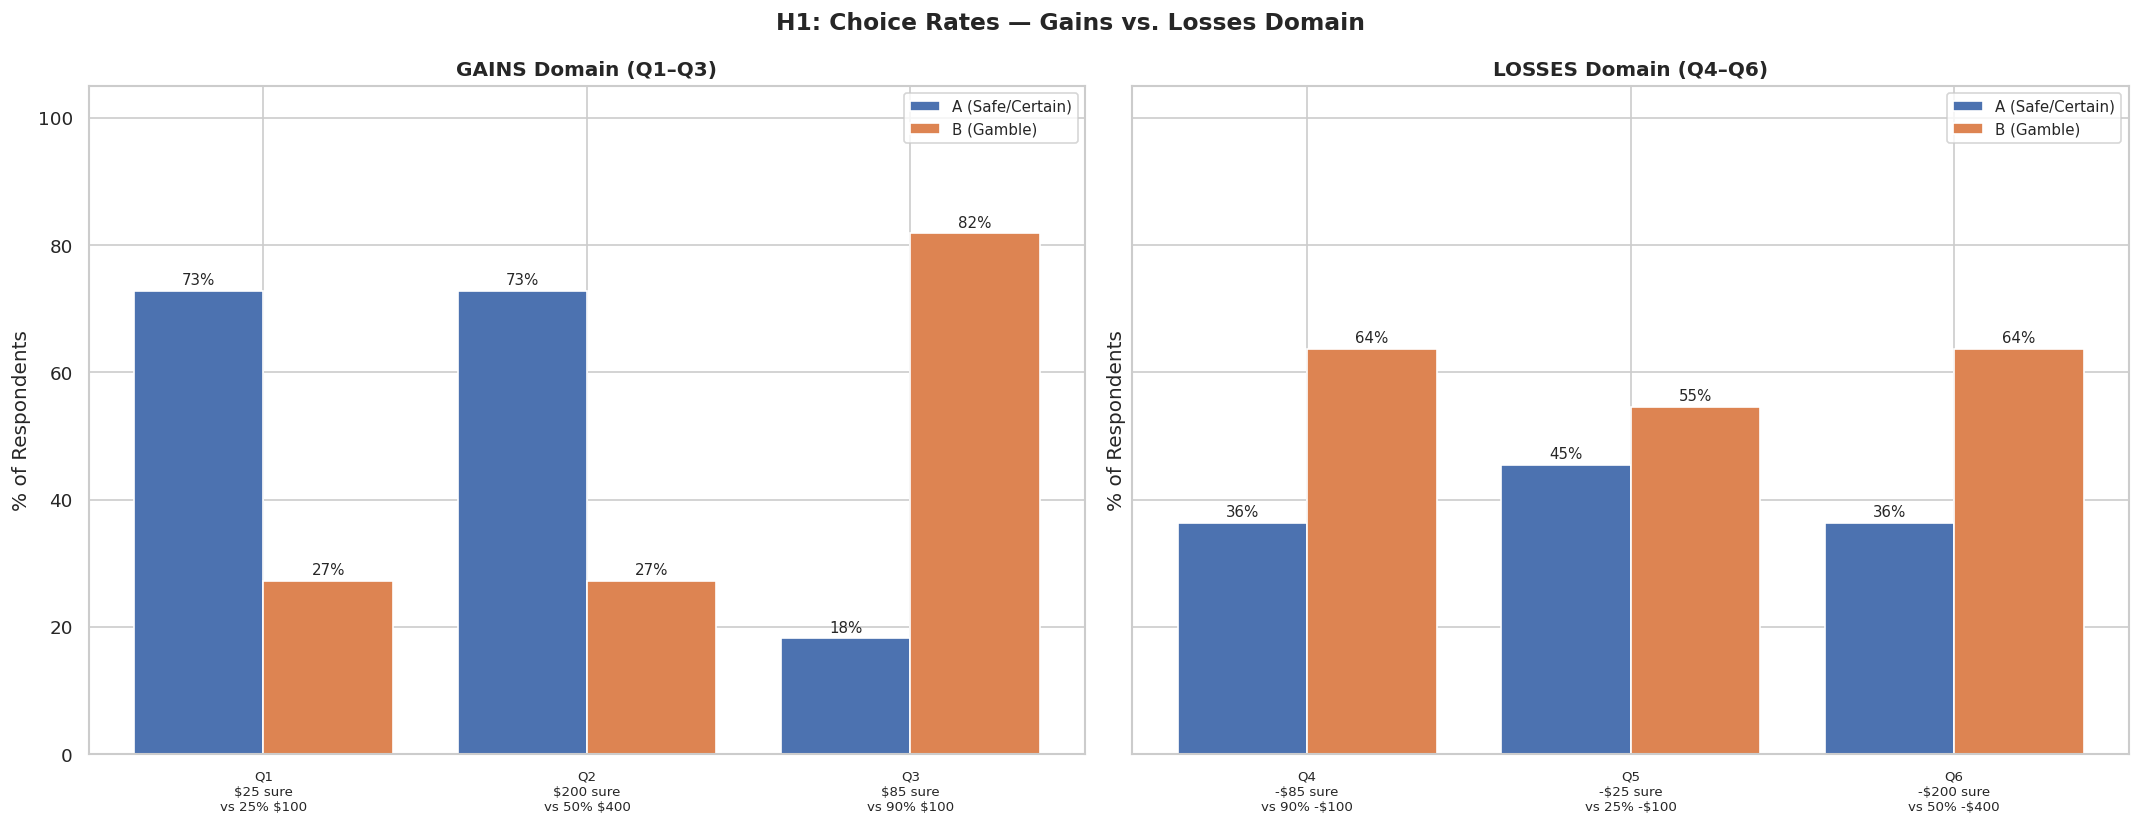

/tmp/ipykernel_11791/1669690408.py:154: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x="Domain", y="Score", data=data_long, ax=axes[0],


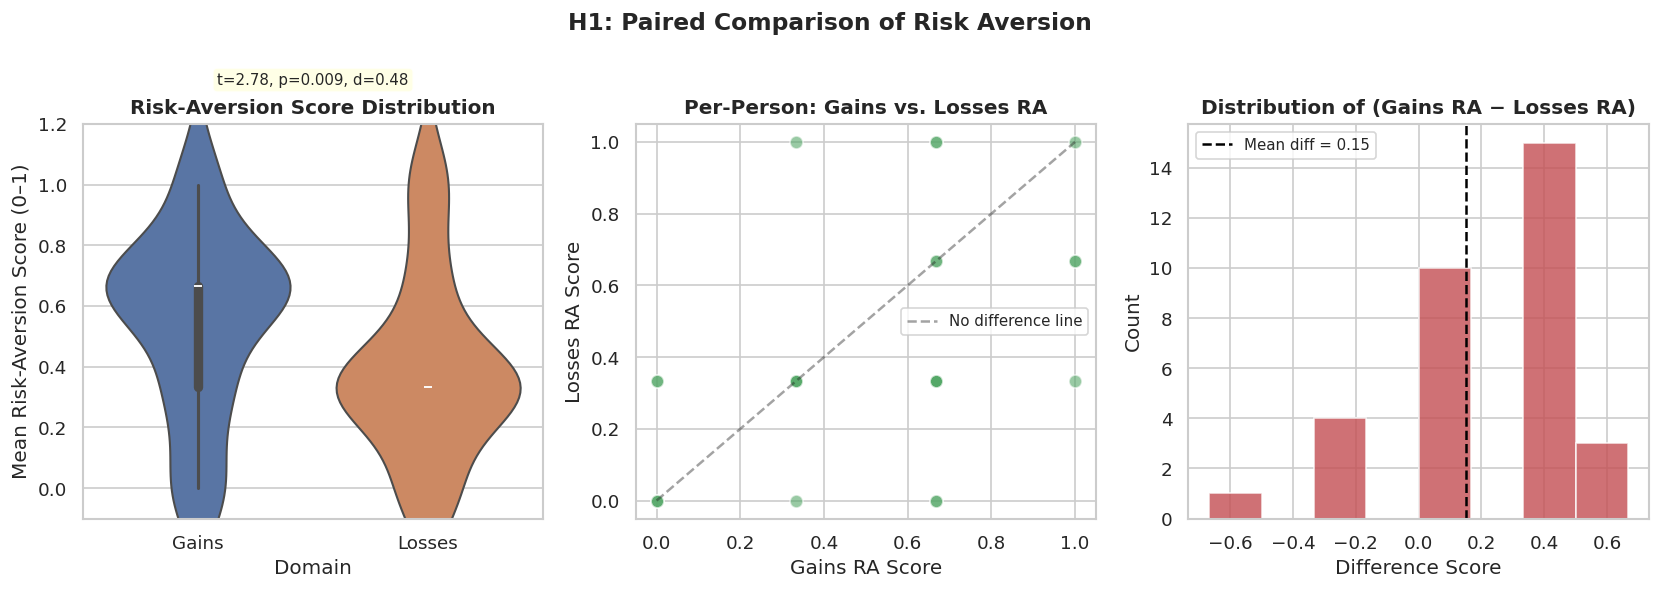

H1 Stats → t=2.782, p=0.0090, Cohen's d=0.484


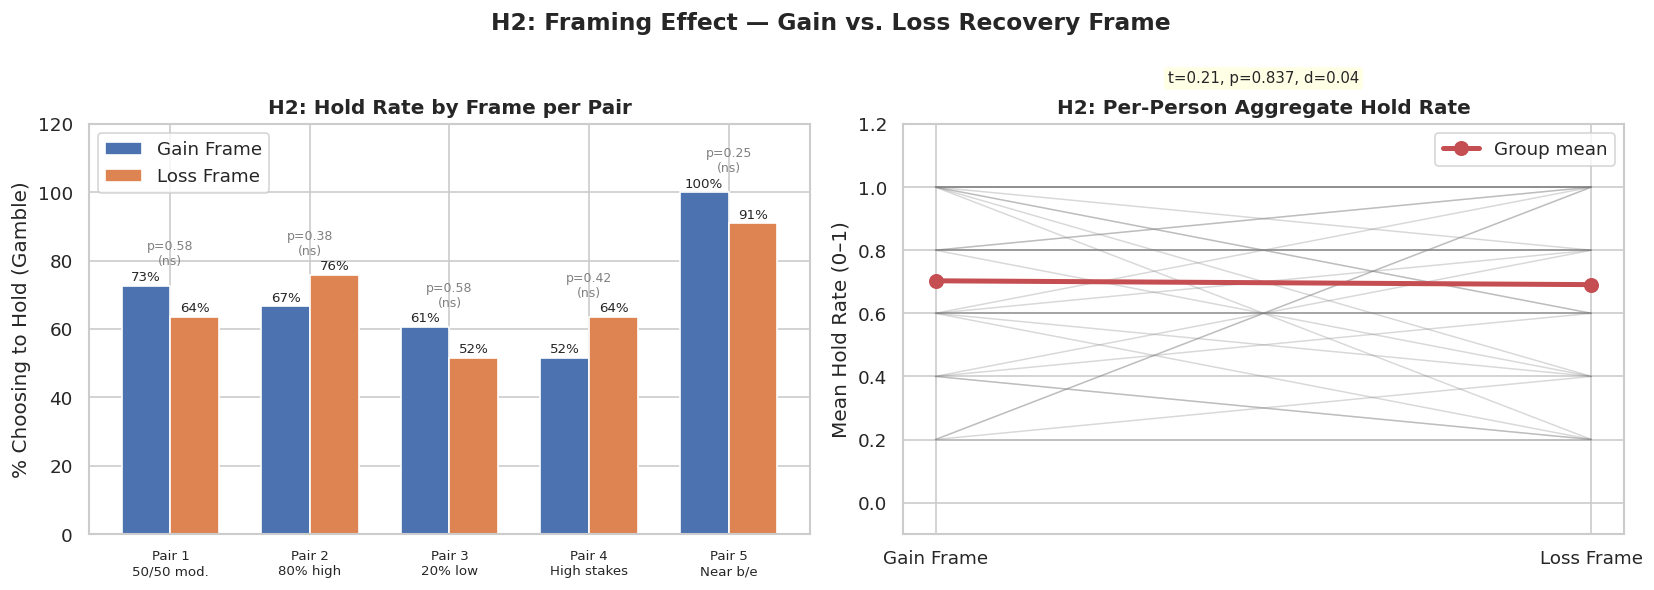

H2 Aggregate → t=0.208, p=0.8367, Cohen's d=0.036


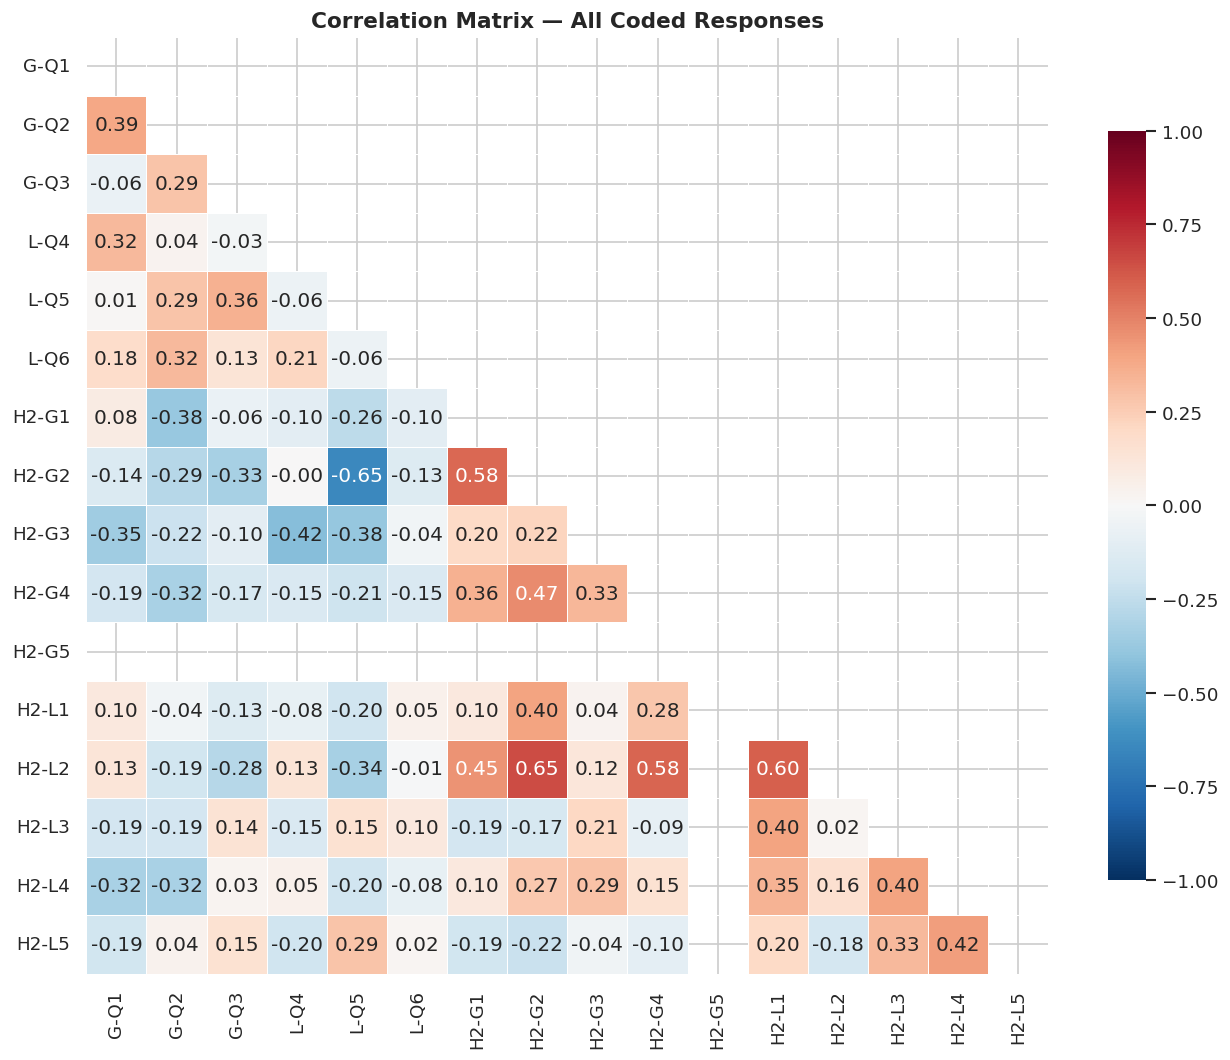

                    Question Domain  % Safe (A)  % Gamble (B)
   Q1\n$25 sure\nvs 25% $100   Gain        72.7          27.3
  Q2\n$200 sure\nvs 50% $400   Gain        72.7          27.3
   Q3\n$85 sure\nvs 90% $100   Gain        18.2          81.8
 Q4\n-$85 sure\nvs 90% -$100   Loss        36.4          63.6
 Q5\n-$25 sure\nvs 25% -$100   Loss        45.5          54.5
Q6\n-$200 sure\nvs 50% -$400   Loss        36.4          63.6
        H2 Pair 1 50/50 mod.     H2        27.3          72.7
          H2 Pair 2 80% high     H2        33.3          66.7
           H2 Pair 3 20% low     H2        39.4          60.6
       H2 Pair 4 High stakes     H2        48.5          51.5
          H2 Pair 5 Near b/e     H2         0.0         100.0
RESULTS SUMMARY

H1 — Reflection Effect
  Gains RA:  0.545 (54.5%)
  Losses RA: 0.394 (39.4%)
  Paired t(32) = 2.782, p = 0.0090
  Cohen's d = 0.484  → SUPPORTED ✅

H2 — Framing Effect
  Gain frame hold:  0.703
  Loss frame hold:  0.691
  Paired t(32) = 0.

In [7]:
"""
Prospect Theory Survey — Exploratory Data Analysis
COGS 180 Project
Run in Jupyter: jupyter lab prospect_theory_eda.py
Or convert: jupytext --to notebook prospect_theory_eda.py
"""

# %% [markdown]
# # Prospect Theory Survey — EDA
# **H1:** Loss aversion & reflection effect (Q1–Q6)
# **H2:** Framing effect in stock scenarios (Q1–Q10)

# %% Setup
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 120

df = pd.read_csv("COGS180.csv")
print(f"Dataset shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")
df.head(3)

# %% [markdown]
# ## 1. Sample Demographics

# %%
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Age distribution
df["What is your age?"].plot(kind="hist", bins=10, ax=axes[0], color="#4C72B0", edgecolor="white")
axes[0].set_title("Age Distribution", fontsize=13, fontweight="bold")
axes[0].set_xlabel("Age")
axes[0].set_ylabel("Count")
axes[0].axvline(df["What is your age?"].mean(), color="red", linestyle="--", label=f'Mean = {df["What is your age?"].mean():.1f}')
axes[0].legend()

# Occupation
occ_counts = df["Occupitation"].str.strip().str.lower().str.capitalize().value_counts()
occ_counts.plot(kind="bar", ax=axes[1], color="#DD8452", edgecolor="white")
axes[1].set_title("Occupation Breakdown", fontsize=13, fontweight="bold")
axes[1].set_xlabel("")
axes[1].set_ylabel("Count")
axes[1].tick_params(axis="x", rotation=30)

plt.suptitle("Sample Demographics  (N=33)", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("fig1_demographics.png", bbox_inches="tight")
plt.show()
print(f"N = {len(df)} | Age: M={df['What is your age?'].mean():.1f}, SD={df['What is your age?'].std():.1f}")


# %% [markdown]
# ## 2. Binary Coding

# %%
def code_A(series):
    """1 = chose A (safe/risk-averse), 0 = chose B (gamble/risk-seeking)"""
    return series.str.startswith("A").astype(int)

# H1 columns
h1_gain_cols  = ["P1.Q1", "P1.Q2", "P1.Q3"]
h1_loss_cols  = ["P1.Q4", "P1.Q5", "P1.Q6"]

h1_labels = {
    "P1.Q1": "Q1\n$25 sure\nvs 25% $100",
    "P1.Q2": "Q2\n$200 sure\nvs 50% $400",
    "P1.Q3": "Q3\n$85 sure\nvs 90% $100",
    "P1.Q4": "Q4\n-$85 sure\nvs 90% -$100",
    "P1.Q5": "Q5\n-$25 sure\nvs 25% -$100",
    "P1.Q6": "Q6\n-$200 sure\nvs 50% -$400",
}

for c in h1_gain_cols + h1_loss_cols:
    df[c + "_coded"] = code_A(df[c])

# H2 columns — B = hold (gamble)
h2_pairs = {
    "Pair 1\n50/50 mod.":  ("P2.Q1", "P2.Q2"),
    "Pair 2\n80% high":    ("P2.Q3", "P2.Q4"),
    "Pair 3\n20% low":     ("P2.Q5", "P2.Q6"),
    "Pair 4\nHigh stakes": ("P2.Q7", "P2.Q8"),
    "Pair 5\nNear b/e":    ("P2.Q9", "P2.Q10"),
}

for label, (gq, lq) in h2_pairs.items():
    df[gq + "_hold"] = (~df[gq].str.startswith("A")).astype(int)
    df[lq + "_hold"] = (~df[lq].str.startswith("A")).astype(int)

print("Binary coding complete.")


# %% [markdown]
# ## 3. H1 — Choice Rates per Question

# %%
fig, axes = plt.subplots(1, 2, figsize=(18, 7), sharey=True)

colors_A = "#4C72B0"
colors_B = "#DD8452"

for ax, cols, title, domain in [
    (axes[0], h1_gain_cols, "GAINS Domain (Q1–Q3)", "gain"),
    (axes[1], h1_loss_cols, "LOSSES Domain (Q4–Q6)", "loss"),
]:
    pct_A = [df[c + "_coded"].mean() * 100 for c in cols]
    pct_B = [100 - p for p in pct_A]
    labels = [h1_labels[c] for c in cols]
    x = np.arange(len(cols))

    ax.bar(x - 0.2, pct_A, width=0.4, label="A (Safe/Certain)", color=colors_A, edgecolor="white")
    ax.bar(x + 0.2, pct_B, width=0.4, label="B (Gamble)", color=colors_B, edgecolor="white")

    for i, (a, b) in enumerate(zip(pct_A, pct_B)):
        ax.text(i - 0.2, a + 1, f"{a:.0f}%", ha="center", fontsize=9)
        ax.text(i + 0.2, b + 1, f"{b:.0f}%", ha="center", fontsize=9)

    ax.set_xticks(x)
    ax.set_xticklabels(labels, fontsize=8)
    ax.set_title(title, fontsize=12, fontweight="bold")
    ax.set_ylabel("% of Respondents")
    ax.set_ylim(0, 105)
    ax.legend(fontsize=9)

plt.suptitle("H1: Choice Rates — Gains vs. Losses Domain", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("fig2_h1_choice_rates.png", bbox_inches="tight")
plt.show()


# %% [markdown]
# ## 4. H1 — Risk-Aversion Score per Person (Paired Comparison)

# %%
df["gains_RA"]  = df[[c + "_coded" for c in h1_gain_cols]].mean(axis=1)
df["losses_RA"] = df[[c + "_coded" for c in h1_loss_cols]].mean(axis=1)

t_stat, p_val = stats.ttest_rel(df["gains_RA"], df["losses_RA"])
diff = df["gains_RA"] - df["losses_RA"]
cohens_d = diff.mean() / diff.std()

fig, axes = plt.subplots(1, 3, figsize=(14, 5))

# Violin / box
data_long = pd.DataFrame({
    "Score": pd.concat([df["gains_RA"], df["losses_RA"]], ignore_index=True),
    "Domain": ["Gains"] * len(df) + ["Losses"] * len(df)
})
sns.violinplot(x="Domain", y="Score", data=data_long, ax=axes[0],
               palette={"Gains": "#4C72B0", "Losses": "#DD8452"}, inner="box")
axes[0].set_title("Risk-Aversion Score Distribution", fontweight="bold")
axes[0].set_ylabel("Mean Risk-Aversion Score (0–1)")
axes[0].set_ylim(-0.1, 1.2)
axes[0].text(0.5, 1.1, f"t={t_stat:.2f}, p={p_val:.3f}, d={cohens_d:.2f}",
             ha="center", transform=axes[0].transAxes, fontsize=9,
             bbox=dict(boxstyle="round", facecolor="lightyellow", alpha=0.8))

# Scatter: gains vs losses per person
axes[1].scatter(df["gains_RA"], df["losses_RA"], alpha=0.6, color="#55A868", edgecolor="white", s=60)
axes[1].plot([0, 1], [0, 1], "k--", alpha=0.4, label="No difference line")
axes[1].set_xlabel("Gains RA Score")
axes[1].set_ylabel("Losses RA Score")
axes[1].set_title("Per-Person: Gains vs. Losses RA", fontweight="bold")
axes[1].legend(fontsize=9)

# Difference histogram
axes[2].hist(diff, bins=8, color="#C44E52", edgecolor="white", alpha=0.8)
axes[2].axvline(diff.mean(), color="black", linestyle="--", label=f"Mean diff = {diff.mean():.2f}")
axes[2].set_title("Distribution of (Gains RA − Losses RA)", fontweight="bold")
axes[2].set_xlabel("Difference Score")
axes[2].set_ylabel("Count")
axes[2].legend(fontsize=9)

plt.suptitle("H1: Paired Comparison of Risk Aversion", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("fig3_h1_paired.png", bbox_inches="tight")
plt.show()
print(f"H1 Stats → t={t_stat:.3f}, p={p_val:.4f}, Cohen's d={cohens_d:.3f}")


# %% [markdown]
# ## 5. H2 — Hold Rate: Gain Frame vs. Loss Frame

# %%
pair_labels = list(h2_pairs.keys())
gain_rates  = []
loss_rates  = []
p_values    = []

for label, (gq, lq) in h2_pairs.items():
    g = df[gq + "_hold"]
    l = df[lq + "_hold"]
    gain_rates.append(g.mean() * 100)
    loss_rates.append(l.mean() * 100)
    # McNemar via exact binomial on discordant pairs
    b = ((g == 1) & (l == 0)).sum()
    c = ((g == 0) & (l == 1)).sum()
    n = b + c
    p = 2 * min(stats.binom.cdf(b, n, 0.5), stats.binom.cdf(c, n, 0.5)) if n > 0 else 1.0
    p_values.append(p)

x = np.arange(len(pair_labels))
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Grouped bar
w = 0.35
bars1 = axes[0].bar(x - w/2, gain_rates, width=w, label="Gain Frame", color="#4C72B0", edgecolor="white")
bars2 = axes[0].bar(x + w/2, loss_rates, width=w, label="Loss Frame", color="#DD8452", edgecolor="white")
for i, (g, l, p) in enumerate(zip(gain_rates, loss_rates, p_values)):
    axes[0].text(i - w/2, g + 1.5, f"{g:.0f}%", ha="center", fontsize=8)
    axes[0].text(i + w/2, l + 1.5, f"{l:.0f}%", ha="center", fontsize=8)
    sig = "***" if p < .001 else "**" if p < .01 else "*" if p < .05 else "ns"
    axes[0].text(i, max(g, l) + 6, f"p={p:.2f}\n({sig})", ha="center", fontsize=7.5, color="gray")
axes[0].set_xticks(x)
axes[0].set_xticklabels(pair_labels, fontsize=8)
axes[0].set_ylabel("% Choosing to Hold (Gamble)")
axes[0].set_ylim(0, 120)
axes[0].set_title("H2: Hold Rate by Frame per Pair", fontweight="bold")
axes[0].legend()

# Paired slope (spaghetti) plot for each participant across all pairs
gain_person = pd.concat([df[gq + "_hold"] for _, (gq, _) in h2_pairs.items()], axis=1).mean(axis=1)
loss_person = pd.concat([df[lq + "_hold"] for _, (_, lq) in h2_pairs.items()], axis=1).mean(axis=1)

for g, l in zip(gain_person, loss_person):
    axes[1].plot([0, 1], [g, l], color="gray", alpha=0.3, linewidth=0.9)
axes[1].plot([0, 1], [gain_person.mean(), loss_person.mean()], color="#C44E52",
             linewidth=3, marker="o", markersize=8, label="Group mean")
axes[1].set_xticks([0, 1])
axes[1].set_xticklabels(["Gain Frame", "Loss Frame"], fontsize=11)
axes[1].set_ylabel("Mean Hold Rate (0–1)")
axes[1].set_ylim(-0.1, 1.2)
axes[1].set_title("H2: Per-Person Aggregate Hold Rate", fontweight="bold")
axes[1].legend()
t2, p2 = stats.ttest_rel(gain_person, loss_person)
d2 = (gain_person - loss_person).mean() / (gain_person - loss_person).std()
axes[1].text(0.5, 1.1, f"t={t2:.2f}, p={p2:.3f}, d={d2:.2f}",
             ha="center", transform=axes[1].transAxes, fontsize=9,
             bbox=dict(boxstyle="round", facecolor="lightyellow", alpha=0.8))

plt.suptitle("H2: Framing Effect — Gain vs. Loss Recovery Frame", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("fig4_h2_framing.png", bbox_inches="tight")
plt.show()
print(f"H2 Aggregate → t={t2:.3f}, p={p2:.4f}, Cohen's d={d2:.3f}")


# %% [markdown]
# ## 6. Correlation Heatmap — All H1 & H2 Questions

# %%
coded_cols = (
    [c + "_coded" for c in h1_gain_cols + h1_loss_cols] +
    [gq + "_hold" for _, (gq, _) in h2_pairs.items()] +
    [lq + "_hold" for _, (_, lq) in h2_pairs.items()]
)
nice_labels = (
    ["G-Q1","G-Q2","G-Q3","L-Q4","L-Q5","L-Q6"] +
    [f"H2-G{i+1}" for i in range(5)] +
    [f"H2-L{i+1}" for i in range(5)]
)

corr = df[coded_cols].rename(columns=dict(zip(coded_cols, nice_labels))).corr()

fig, ax = plt.subplots(figsize=(11, 9))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="RdBu_r",
            center=0, vmin=-1, vmax=1, ax=ax, linewidths=0.4,
            cbar_kws={"shrink": 0.8})
ax.set_title("Correlation Matrix — All Coded Responses", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("fig5_correlation.png", bbox_inches="tight")
plt.show()


# %% [markdown]
# ## 7. Summary Stats Table

# %%
summary = pd.DataFrame({
    "Question": list(h1_labels.values()) + [f"H2 {l.replace(chr(10),' ')}" for l in pair_labels],
    "Domain": (["Gain"]*3 + ["Loss"]*3 + ["H2"]*5),
    "% Safe (A)": (
        [df[c+"_coded"].mean()*100 for c in h1_gain_cols+h1_loss_cols] +
        [(1 - df[gq+"_hold"].mean())*100 for _,(gq,_) in h2_pairs.items()]
    ),
    "% Gamble (B)": (
        [(1-df[c+"_coded"].mean())*100 for c in h1_gain_cols+h1_loss_cols] +
        [df[gq+"_hold"].mean()*100 for _,(gq,_) in h2_pairs.items()]
    ),
})
summary = summary.round(1)
print(summary.to_string(index=False))


# %% [markdown]
# ## 8. Overall Results Summary

# %%
print("=" * 50)
print("RESULTS SUMMARY")
print("=" * 50)
print(f"\nH1 — Reflection Effect")
print(f"  Gains RA:  {df['gains_RA'].mean():.3f} ({df['gains_RA'].mean()*100:.1f}%)")
print(f"  Losses RA: {df['losses_RA'].mean():.3f} ({df['losses_RA'].mean()*100:.1f}%)")
print(f"  Paired t({len(df)-1}) = {t_stat:.3f}, p = {p_val:.4f}")
print(f"  Cohen's d = {cohens_d:.3f}  → {'SUPPORTED ✅' if p_val < .05 else 'NOT SUPPORTED ❌'}")
print(f"\nH2 — Framing Effect")
print(f"  Gain frame hold:  {gain_person.mean():.3f}")
print(f"  Loss frame hold:  {loss_person.mean():.3f}")
print(f"  Paired t({len(df)-1}) = {t2:.3f}, p = {p2:.4f}")
print(f"  Cohen's d = {d2:.3f}  → {'SUPPORTED ✅' if p2 < .05 else 'NOT SUPPORTED ❌'}")
print("=" * 50)

LLM data loaded. Runs detected: 5
run_id                     1         2         3         4         5
model_short domain                                                  
Gemma 2     Gains   0.666667  0.333333  0.666667  0.666667  0.666667
            Losses  0.000000  0.000000  0.000000  0.000000  0.000000
LLaMA 3.1   Gains   0.333333  0.333333  0.333333  0.333333  0.333333
            Losses  1.000000  1.000000  0.666667  1.000000  0.666667
Qwen 2.5    Gains   1.000000  1.000000  1.000000  1.000000  1.000000
            Losses  1.000000  1.000000  1.000000  1.000000  1.000000


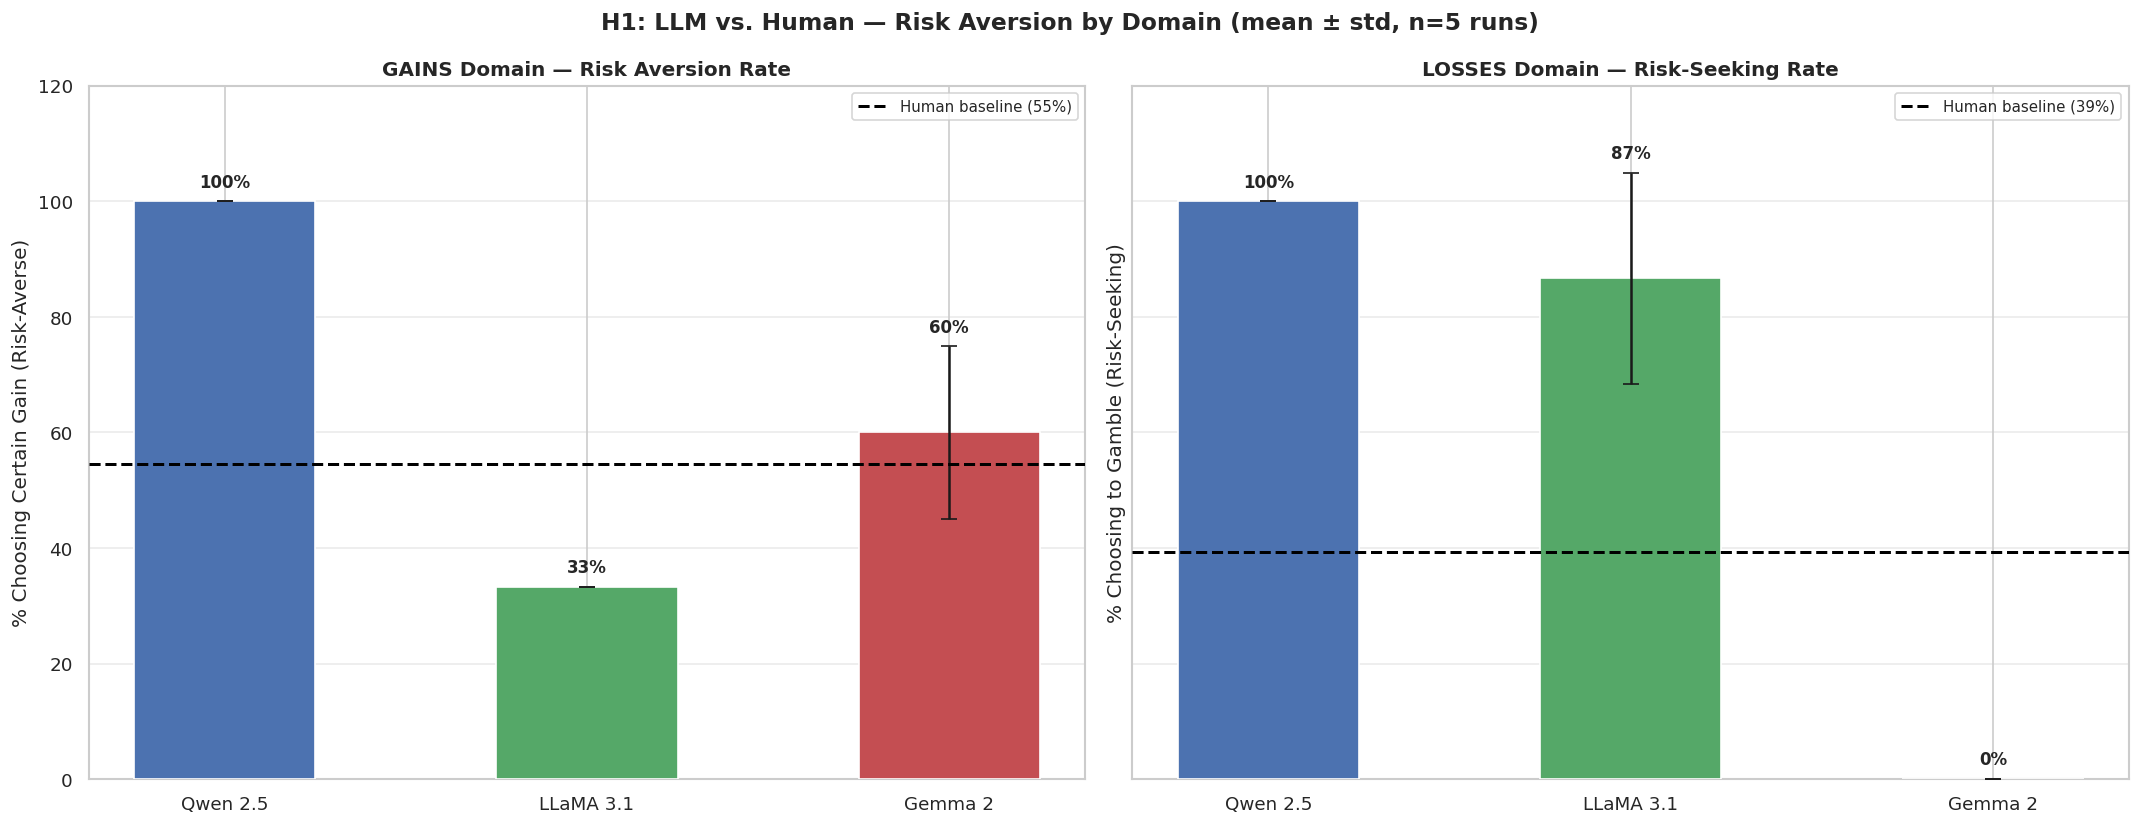

/tmp/ipykernel_11791/4245806.py:176: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


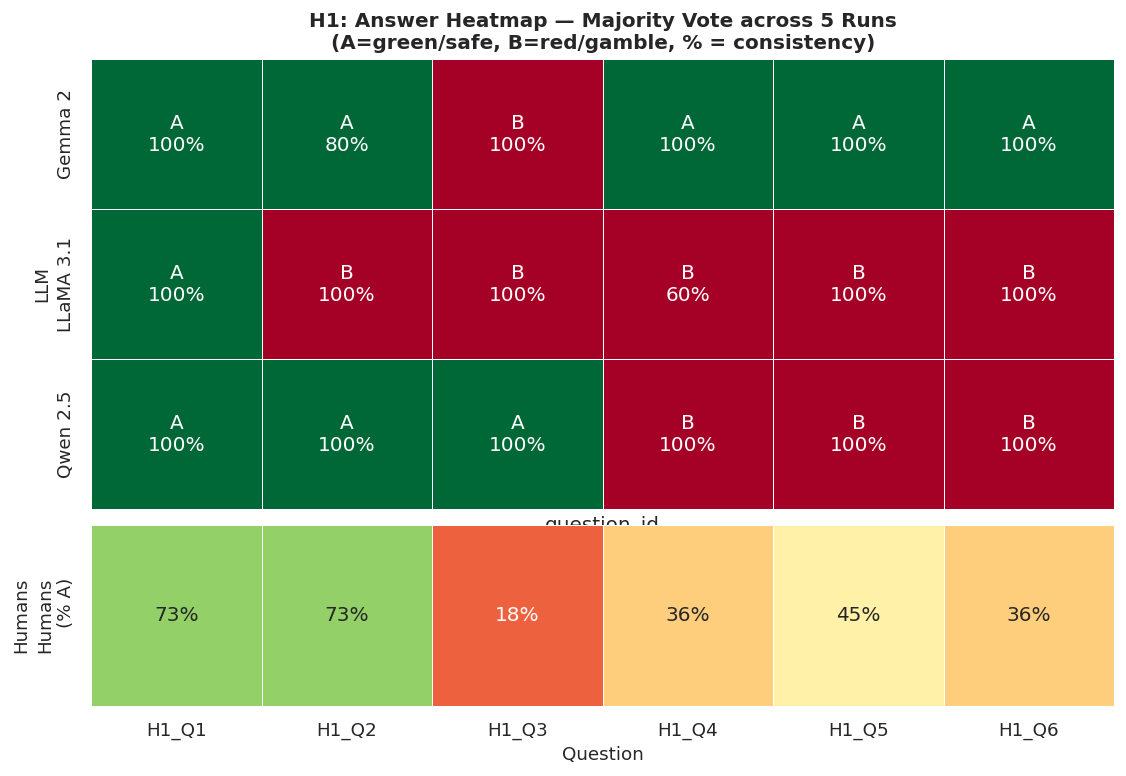

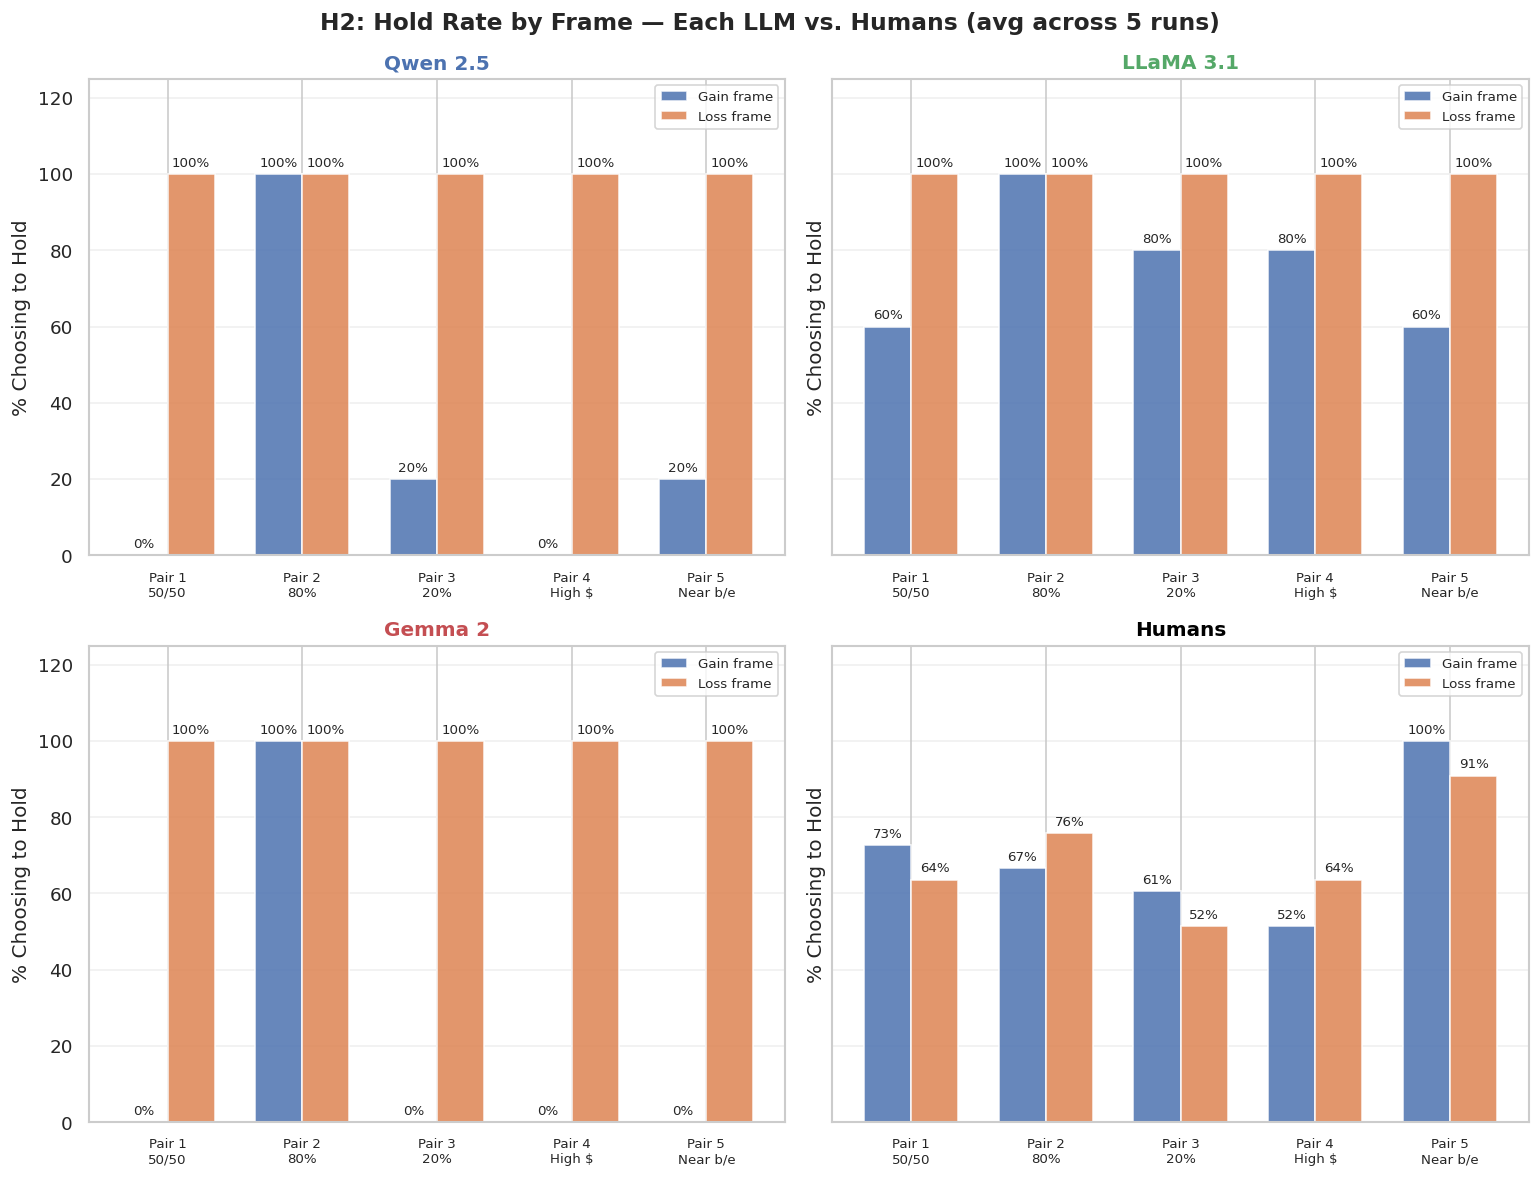

/tmp/ipykernel_11791/4245806.py:300: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


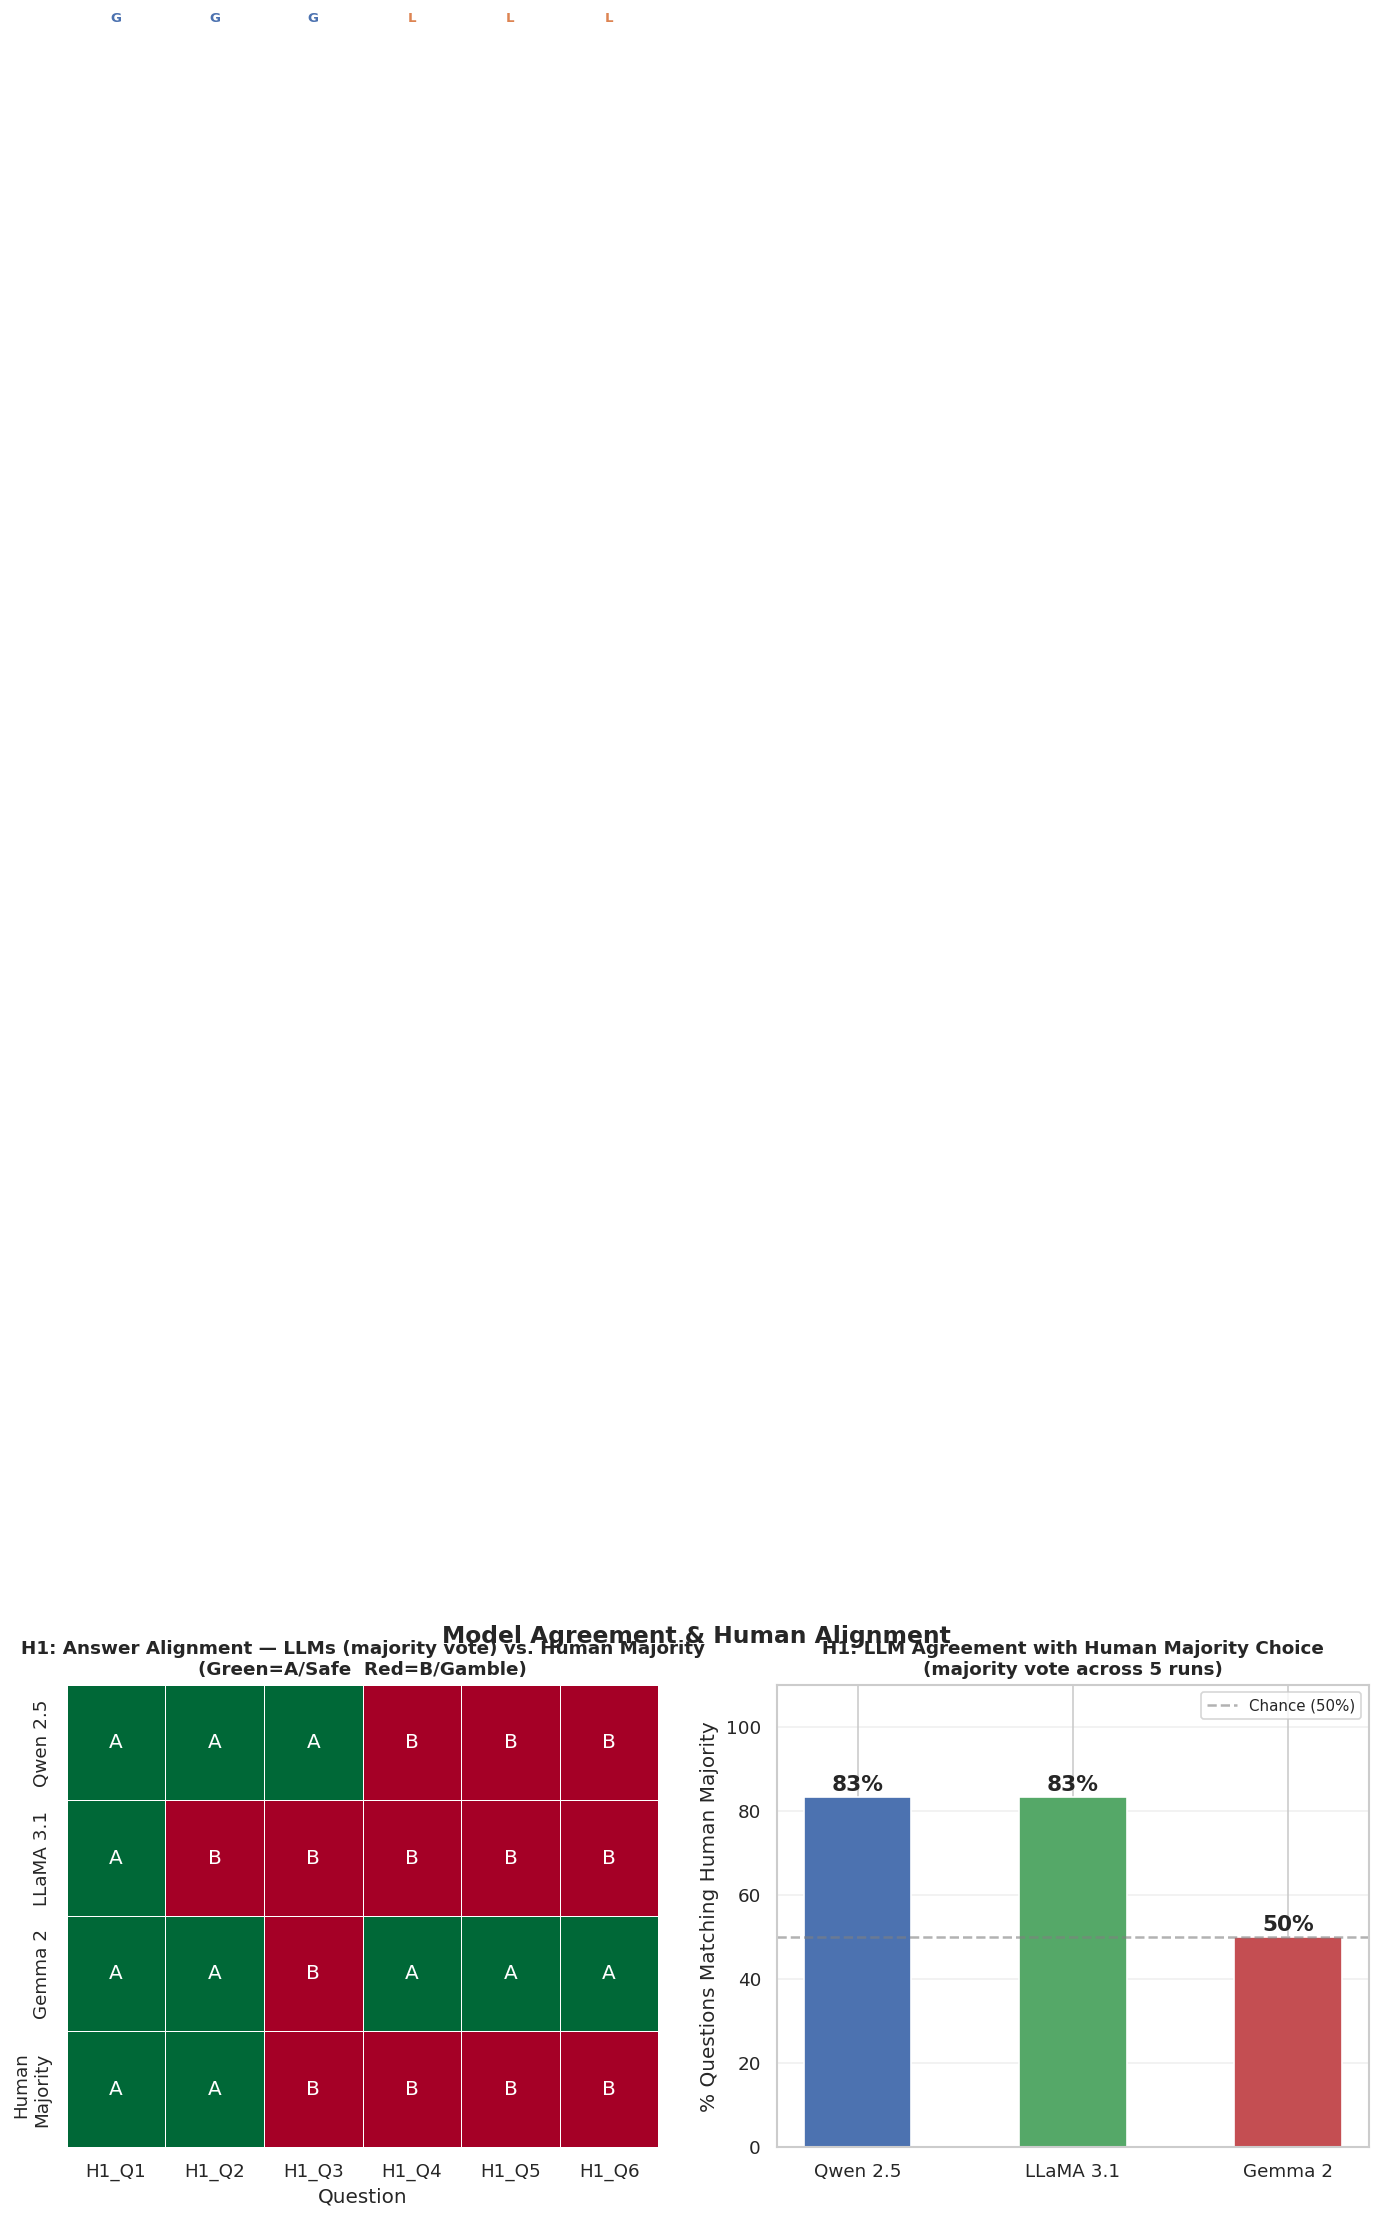


Agreement with human majority (H1, majority vote across 5 runs):
  Qwen 2.5: 83%
  LLaMA 3.1: 83%
  Gemma 2: 50%

Answer consistency across 5 runs (avg % matching majority):
  Qwen 2.5: 100.0%
  LLaMA 3.1: 93.3%
  Gemma 2: 96.7%


In [8]:
# ============================================================
# LLM ANALYSIS — Sections 9–13 (Multi-run aware)
# ============================================================

# %% [markdown]
# ## 9. Load & Prep LLM Data

# %%
# Load the combined multi-run CSV
llm_df = pd.read_csv("./results/results_ALL_5runs_20260313_014112.csv")
llm_df = llm_df[llm_df['answer'].isin(['A','B'])].copy()
llm_df['model_short'] = llm_df['model'].map({
    'qwen2.5:7b':  'Qwen 2.5',
    'llama3.1:8b': 'LLaMA 3.1',
    'gemma2:9b':   'Gemma 2'
})

gain_qids = ['H1_Q1','H1_Q2','H1_Q3']
loss_qids = ['H1_Q4','H1_Q5','H1_Q6']

h1_llm = llm_df[llm_df['section'] == 'H1'].copy()
h1_llm['risk_averse'] = np.where(
    h1_llm['question_id'].isin(gain_qids),
    (h1_llm['answer']=='A').astype(int),
    (h1_llm['answer']=='B').astype(int)
)
h1_llm['domain'] = np.where(h1_llm['question_id'].isin(gain_qids), 'Gains', 'Losses')

h2_llm = llm_df[llm_df['section'] == 'H2'].copy()
h2_llm = h2_llm[h2_llm['frame'].isin(['gain','loss'])].copy()
h2_llm['hold'] = (h2_llm['answer'] == 'B').astype(int)

models_llm   = ['Qwen 2.5', 'LLaMA 3.1', 'Gemma 2']
model_colors = {'Qwen 2.5': '#4C72B0', 'LLaMA 3.1': '#55A868', 'Gemma 2': '#C44E52'}

# --- Majority vote helper ---
def majority_vote(series):
    """Return the most common answer across runs. Ties broken by 'A'."""
    counts = series.value_counts()
    return counts.index[0] if len(counts) > 0 else '?'

# --- Per-question majority vote across runs ---
# For each model × question, compute: majority answer, % choosing A, consistency
def compute_question_stats(df, question_ids):
    """Aggregate per model × question across all runs."""
    rows = []
    for m in models_llm:
        for qid in question_ids:
            sub = df[(df['model_short']==m) & (df['question_id']==qid)]
            if len(sub) == 0:
                continue
            n_runs    = len(sub)
            pct_A     = (sub['answer']=='A').mean()
            majority  = 'A' if pct_A >= 0.5 else 'B'
            # Consistency = % of runs that match the majority answer
            consistency = max(pct_A, 1 - pct_A)
            rows.append({
                'model_short':   m,
                'question_id':   qid,
                'n_runs':        n_runs,
                'pct_A':         pct_A,
                'majority':      majority,
                'consistency':   consistency,
            })
    return pd.DataFrame(rows)

h1_stats = compute_question_stats(h1_llm, gain_qids + loss_qids)

human_pct_A = {
    'H1_Q1': df['P1.Q1_coded'].mean(), 'H1_Q2': df['P1.Q2_coded'].mean(),
    'H1_Q3': df['P1.Q3_coded'].mean(), 'H1_Q4': df['P1.Q4_coded'].mean(),
    'H1_Q5': df['P1.Q5_coded'].mean(), 'H1_Q6': df['P1.Q6_coded'].mean(),
}

human_gains_ra  = df["gains_RA"].mean()
human_losses_ra = df["losses_RA"].mean()

n_runs = llm_df['run_id'].nunique()
print(f"LLM data loaded. Runs detected: {n_runs}")
print(h1_llm.groupby(['model_short','domain','run_id'])['risk_averse'].mean().unstack('run_id'))


# %% [markdown]
# ## 10. H1 — Risk Aversion by Domain (averaged across runs, with variance bars)

# %%
fig, axes = plt.subplots(1, 2, figsize=(18, 7), sharey=True)

for ax, domain, human_val, title, ylabel in [
    (axes[0], 'Gains',  human_gains_ra,  'GAINS Domain — Risk Aversion Rate',  '% Choosing Certain Gain (Risk-Averse)'),
    (axes[1], 'Losses', human_losses_ra, 'LOSSES Domain — Risk-Seeking Rate',  '% Choosing to Gamble (Risk-Seeking)'),
]:
    means, stds = [], []
    for m in models_llm:
        # Per-run averages for this model × domain
        per_run = h1_llm[(h1_llm['model_short']==m) & (h1_llm['domain']==domain)] \
                    .groupby('run_id')['risk_averse'].mean()
        means.append(per_run.mean())
        stds.append(per_run.std())

    x    = np.arange(len(models_llm))
    bars = ax.bar(x, [v*100 for v in means], width=0.5, yerr=[s*100 for s in stds],
                  capsize=5, error_kw={'linewidth': 1.5},
                  color=[model_colors[m] for m in models_llm], edgecolor='white', zorder=3)

    for bar, val, std in zip(bars, means, stds):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height() + std*100 + 2.5,
                f'{val*100:.0f}%', ha='center', fontsize=10, fontweight='bold')

    ax.axhline(human_val*100, color='black', linestyle='--', linewidth=1.8,
               label=f'Human baseline ({human_val*100:.0f}%)', zorder=4)
    ax.set_xticks(x)
    ax.set_xticklabels(models_llm, fontsize=11)
    ax.set_title(title, fontweight='bold', fontsize=12)
    ax.set_ylabel(ylabel)
    ax.set_ylim(0, 120)
    ax.legend(fontsize=9)
    ax.grid(axis='y', alpha=0.4)

plt.suptitle(f'H1: LLM vs. Human — Risk Aversion by Domain (mean ± std, n={n_runs} runs)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('fig6_llm_h1_vs_human.png', bbox_inches='tight')
plt.show()


# %% [markdown]
# ## 11. H1 — Answer Heatmap (majority vote across runs + consistency)

# %%
# Build pivot of majority vote per model × question
majority_pivot = h1_stats.pivot(index='model_short', columns='question_id', values='majority')
majority_pivot = majority_pivot.reindex(columns=gain_qids + loss_qids)

# Consistency pivot (for annotation)
consistency_pivot = h1_stats.pivot(index='model_short', columns='question_id', values='consistency')
consistency_pivot = consistency_pivot.reindex(columns=gain_qids + loss_qids)

# Encode for heatmap: A=1, B=0
encode_majority = majority_pivot.map(lambda v: 1 if v=='A' else 0 if v=='B' else 0.5)

human_row = pd.DataFrame([human_pct_A], index=['Humans\n(% A)'])
human_row.columns.name = 'question_id'

fig, axes = plt.subplots(2, 1, figsize=(11, 7),
                          gridspec_kw={'height_ratios': [3, 1.2], 'hspace': 0.05})

# Annotation: show majority answer + consistency %
annot_llm = majority_pivot.copy().astype(object)
for m in models_llm:
    for qid in gain_qids + loss_qids:
        row = h1_stats[(h1_stats['model_short']==m) & (h1_stats['question_id']==qid)]
        if len(row) == 0: continue
        maj  = row['majority'].values[0]
        cons = row['consistency'].values[0]
        annot_llm.loc[m, qid] = f"{maj}\n{cons*100:.0f}%"

sns.heatmap(encode_majority, ax=axes[0], cmap='RdYlGn', vmin=0, vmax=1,
            annot=annot_llm, fmt='s', linewidths=0.5, cbar=False, xticklabels=False)
axes[0].set_ylabel('LLM', fontsize=11)
axes[0].set_title(f'H1: Answer Heatmap — Majority Vote across {n_runs} Runs\n(A=green/safe, B=red/gamble, % = consistency)',
                   fontsize=12, fontweight='bold')

for i, qid in enumerate(gain_qids + loss_qids):
    color = '#4C72B0' if qid in gain_qids else '#DD8452'
    axes[0].text(i+0.5, -0.3, 'GAIN' if qid in gain_qids else 'LOSS',
                 ha='center', va='top', fontsize=7.5, color=color, fontweight='bold',
                 transform=axes[0].get_xaxis_transform())

sns.heatmap(human_row, ax=axes[1], cmap='RdYlGn', vmin=0, vmax=1,
            annot=human_row.map(lambda v: f'{v*100:.0f}%'), fmt='s',
            linewidths=0.5, cbar=False)
axes[1].set_ylabel('Humans', fontsize=11)
axes[1].set_xlabel('Question', fontsize=11)

plt.tight_layout()
plt.savefig('fig7_llm_h1_heatmap.png', bbox_inches='tight')
plt.show()


# %% [markdown]
# ## 12. H2 — Framing Effect: LLM vs. Human Hold Rates (averaged across runs)

# %%
pair_labels_short = ['Pair 1\n50/50', 'Pair 2\n80%', 'Pair 3\n20%', 'Pair 4\nHigh $', 'Pair 5\nNear b/e']
pairs_num = [1, 2, 3, 4, 5]

h2_human_pairs = {
    1:('P2.Q1','P2.Q2'), 2:('P2.Q3','P2.Q4'),
    3:('P2.Q5','P2.Q6'), 4:('P2.Q7','P2.Q8'), 5:('P2.Q9','P2.Q10')
}
human_gain_hold = [(~df[gq].str.startswith('A')).mean()*100 for gq,_ in h2_human_pairs.values()]
human_loss_hold = [(~df[lq].str.startswith('A')).mean()*100 for _,lq in h2_human_pairs.values()]

# Average hold rate across runs per model × pair × frame
all_gain = {m: [] for m in models_llm}
all_loss = {m: [] for m in models_llm}
for m in models_llm:
    for p in pairs_num:
        sub = h2_llm[(h2_llm['model_short']==m) & (h2_llm['pair']==p)]
        g = sub[sub['frame']=='gain'].groupby('run_id')['hold'].mean().mean() \
            if len(sub[sub['frame']=='gain']) else np.nan
        l = sub[sub['frame']=='loss'].groupby('run_id')['hold'].mean().mean() \
            if len(sub[sub['frame']=='loss']) else np.nan
        all_gain[m].append(g*100 if not np.isnan(g) else np.nan)
        all_loss[m].append(l*100 if not np.isnan(l) else np.nan)

x = np.arange(len(pairs_num))
w = 0.35
fig, axes_grid = plt.subplots(2, 2, figsize=(13, 10), sharey=True)
axes = [axes_grid[0,0], axes_grid[0,1], axes_grid[1,0], axes_grid[1,1]]

all_subjects = models_llm + ['Humans']
all_g_vals   = [all_gain[m] for m in models_llm] + [human_gain_hold]
all_l_vals   = [all_loss[m] for m in models_llm] + [human_loss_hold]

for ax, subject, g_vals, l_vals in zip(axes, all_subjects, all_g_vals, all_l_vals):
    b1 = ax.bar(x-w/2, g_vals, width=w, color='#4C72B0', edgecolor='white', label='Gain frame', alpha=0.85)
    b2 = ax.bar(x+w/2, l_vals, width=w, color='#DD8452', edgecolor='white', label='Loss frame', alpha=0.85)
    for bar in list(b1)+list(b2):
        h = bar.get_height()
        if not np.isnan(h):
            ax.text(bar.get_x()+bar.get_width()/2, h+2, f'{h:.0f}%', ha='center', fontsize=8)
    color = model_colors.get(subject, 'black')
    ax.set_title(subject, fontweight='bold', fontsize=12, color=color)
    ax.set_xticks(x)
    ax.set_xticklabels(pair_labels_short, fontsize=8)
    ax.set_ylim(0, 125)
    ax.grid(axis='y', alpha=0.3)
    ax.set_ylabel('% Choosing to Hold')
    ax.legend(fontsize=8, loc='upper right')

plt.suptitle(f'H2: Hold Rate by Frame — Each LLM vs. Humans (avg across {n_runs} runs)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('fig8_llm_h2_framing.png', bbox_inches='tight')
plt.show()


# %% [markdown]
# ## 13. Model Agreement & Human Alignment Summary (majority vote + consistency)

# %%
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Build agree_df using majority vote
agree_rows = []
for qid in gain_qids + loss_qids:
    row = {'Question': qid}
    for m in models_llm:
        r = h1_stats[(h1_stats['model_short']==m) & (h1_stats['question_id']==qid)]
        row[m] = r['majority'].values[0] if len(r) > 0 else '?'
    row['Human\nMajority'] = 'A' if human_pct_A[qid] >= 0.5 else 'B'
    agree_rows.append(row)

agree_df = pd.DataFrame(agree_rows).set_index('Question')
encode   = lambda col: col.map({'A':1,'B':0,'?':0.5})
plot_df  = agree_df.apply(encode)

sns.heatmap(plot_df.T, ax=axes[0], cmap='RdYlGn', vmin=0, vmax=1,
            annot=agree_df.T, fmt='s', linewidths=0.5, cbar=False)
axes[0].set_title('H1: Answer Alignment — LLMs (majority vote) vs. Human Majority\n(Green=A/Safe  Red=B/Gamble)',
                   fontweight='bold', fontsize=11)
axes[0].set_xlabel('Question')

for i, qid in enumerate(gain_qids + loss_qids):
    color = '#4C72B0' if qid in gain_qids else '#DD8452'
    axes[0].text(i+0.5, 4.6, 'G' if qid in gain_qids else 'L',
                 ha='center', fontsize=8, color=color, fontweight='bold',
                 transform=axes[0].get_xaxis_transform())

# Agreement % using majority vote
agreement_scores = {}
for m in models_llm:
    correct = 0
    total   = 0
    for qid in gain_qids + loss_qids:
        r = h1_stats[(h1_stats['model_short']==m) & (h1_stats['question_id']==qid)]
        if len(r) == 0: continue
        human_maj = 'A' if human_pct_A[qid] >= 0.5 else 'B'
        if r['majority'].values[0] == human_maj:
            correct += 1
        total += 1
    agreement_scores[m] = correct / total * 100 if total > 0 else 0

bars = axes[1].bar(list(agreement_scores.keys()), list(agreement_scores.values()),
                   color=[model_colors[m] for m in models_llm], edgecolor='white', width=0.5)
for bar, val in zip(bars, agreement_scores.values()):
    axes[1].text(bar.get_x()+bar.get_width()/2, val+1.5, f'{val:.0f}%',
                 ha='center', fontsize=13, fontweight='bold')
axes[1].axhline(50, color='gray', linestyle='--', alpha=0.6, label='Chance (50%)')
axes[1].set_ylim(0, 110)
axes[1].set_ylabel('% Questions Matching Human Majority')
axes[1].set_title(f'H1: LLM Agreement with Human Majority Choice\n(majority vote across {n_runs} runs)',
                   fontweight='bold', fontsize=11)
axes[1].legend(fontsize=9)
axes[1].grid(axis='y', alpha=0.3)

plt.suptitle('Model Agreement & Human Alignment', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('fig9_llm_agreement.png', bbox_inches='tight')
plt.show()

print(f"\nAgreement with human majority (H1, majority vote across {n_runs} runs):")
for m, s in agreement_scores.items():
    print(f"  {m}: {s:.0f}%")

# Bonus: per-model consistency summary
print(f"\nAnswer consistency across {n_runs} runs (avg % matching majority):")
for m in models_llm:
    avg_cons = h1_stats[h1_stats['model_short']==m]['consistency'].mean()
    print(f"  {m}: {avg_cons*100:.1f}%")